# Empirical Comparison of BIO and BIOES Labeling Schemes for Transformer-Based Named Entity Recognition

We will see BIO, IO, BIOES labeling schemes.

## BIO

In [41]:
# if you need, can be uncommented
!pip install seqeval evaluate

import numpy as np
import pandas as pd
import evaluate

from transformers import DataCollatorForTokenClassification, AutoTokenizer, AutoModelForTokenClassification

from datasets import load_dataset

import torch

In [42]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

n_epochs = 5
batch_size = 64

In [43]:
# create BERT and tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-cased"
)

tokens = tokenizer("Hello, Hugging Face!", return_tensors="pt")
print(tokens)

tokenizer.decode(tokens["input_ids"][0])

{'input_ids': tensor([[  101,  8667,   117, 20164, 10932, 10289,   106,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}


'[CLS] Hello, Hugging Face! [SEP]'

In [44]:
dataset = load_dataset("tomaarsen/conll2003")
print(dataset["train"][0])

{'id': '0', 'document_id': 1, 'sentence_id': 0, 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}


In [45]:
label_names = dataset["train"].features["ner_tags"].feature.names
label_names = list(label_names)

In [46]:
id2labels = dict(enumerate(label_names))
labels2id = {v: k for k, v in id2labels.items()}

print(labels2id)

{'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6, 'B-MISC': 7, 'I-MISC': 8}


In [47]:
example = dataset["train"][2]
print("Original words: ", example["tokens"])
print("Original tags: ", [label_names[t] for t in example["ner_tags"]])
print()

# Tokenize a single sentence
enc = tokenizer(example["tokens"], is_split_into_words=True)

print("Subword tokens: ", enc.tokens())
print("word_ids: ", enc.word_ids())
print()

# word_ids() maps each subword position - original word index (None for [CLS]/[SEP])
print(f"Words: {len(example['tokens'])}, Subword tokens: {len(enc.tokens())}")


Original words:  ['BRUSSELS', '1996-08-22']
Original tags:  ['B-LOC', 'O']

Subword tokens:  ['[CLS]', 'BR', '##US', '##SE', '##LS', '1996', '-', '08', '-', '22', '[SEP]']
word_ids:  [None, 0, 0, 0, 0, 1, 1, 1, 1, 1, None]

Words: 2, Subword tokens: 11



| Subword token | word_id | Original label | Assigned label | Rule |
|---------------|---------|----------------|----------------|------|
| `[CLS]`       | None    | —              | **-100**       | special token - ignore |
| `BR`          | 0       | B-LOC          | **B-LOC**      | first subword - keep label |
| `##US`        | 0       | B-LOC          | **I-LOC**      | continuation - B->I |
| `##SE`        | 0       | B-LOC          | **I-LOC**      | continuation - B->I |
| `##LS`        | 0       | B-LOC          | **I-LOC**      | continuation - B->I |
| `1996`        | 1       | O              | **O**          | first subword - keep label |
| `-`           | 1       | O              | **O**          | continuation - same (O stays O) |
| `08`          | 1       | O              | **O**          | continuation - same |
| `-`           | 1       | O              | **O**          | continuation - same |
| `22`          | 1       | O              | **O**          | continuation - same |
| `[SEP]`       | None    | —              | **-100**       | special token - ignore |


In [48]:
dataset["train"][0]

{'id': '0',
 'document_id': 1,
 'sentence_id': 0,
 'tokens': ['EU',
  'rejects',
  'German',
  'call',
  'to',
  'boycott',
  'British',
  'lamb',
  '.'],
 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7],
 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0],
 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}

In [49]:
label_names

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

In [50]:
# BERT uses a WordPiece tokenizer that splits rare words into subword pieces:
# "Hugging" -> ["Hugging"]                    # 1 token, 1 subword
# "Villanueva" -> ["Villa", "##nu", "##eva"]  # 1 token, 3 subwords
def add_labels(data):
    tokenized = tokenizer(
        data["tokens"],
        truncation=True,
        is_split_into_words=True,
    )

    all_labels = []
    for i, labels in enumerate(data["ner_tags"]):
        ids = tokenized.word_ids(batch_index=i)
        prev_word = None
        new_label = []
        for wid in ids:
            # [CLS], [SEP] get label -100 and are ignored by loss function
            if wid is None:
                new_label.append(-100)
            elif wid != prev_word:
                # first subword of word get original label
                new_label.append(labels[wid])
            else:
                # same label, but B-X converted to I-X
                tag = labels[wid]
                if label_names[tag].startswith("B-"):
                    tag = labels2id["I-" + label_names[tag][2:]]

                new_label.append(tag)
            prev_word = wid

        all_labels.append(new_label)

    tokenized["labels"] = all_labels

    return tokenized

In [51]:
tokenized_ds = dataset.map(
    add_labels,
    batched=True,
    remove_columns=dataset["train"].column_names,
)

In [52]:
# final model token classification
model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=len(label_names),
    id2label=id2labels,
    label2id=labels2id,
)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

In [53]:
metric = evaluate.load("seqeval")

In [54]:
def eval_metric(preds):
    logits, labels = preds
    preds = np.argmax(logits, axis=-1)
    _true, pred = [], []

    for pred_seq, lab_seq in zip(preds, labels):
        tmp_t, tmp_p = [], []
        for p, l in zip(pred_seq, lab_seq):
            if l == -100:
                continue

            tmp_t.append(label_names[int(l)])
            tmp_p.append(label_names[int(p)])

        if tmp_t:
            _true.append(tmp_t)
            pred.append(tmp_p)

    res = metric.compute(predictions=pred, references=_true, zero_division=0)

    return {
        "precision": res["overall_precision"],
        "recall": res["overall_recall"],
        "f1": res["overall_f1"],
        "accuracy": res["overall_accuracy"]
    }

In [55]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    fp16=torch.cuda.is_available(),
    save_strategy="no",
    num_train_epochs=n_epochs,
    logging_dir="./logs",
    logging_steps=100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=eval_metric,
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [56]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
100,0.580957
200,0.115927
300,0.066214
400,0.043013
500,0.030346


TrainOutput(global_step=550, training_loss=0.15429198763587257, metrics={'train_runtime': 428.5996, 'train_samples_per_second': 163.801, 'train_steps_per_second': 1.283, 'total_flos': 2314805530489902.0, 'train_loss': 0.15429198763587257, 'epoch': 5.0})

In [57]:
trainer.predict(tokenized_ds["test"]).metrics

{'test_loss': 0.3422650098800659,
 'test_precision': 0.8790721473648303,
 'test_recall': 0.9125354107648725,
 'test_f1': 0.8954912692207454,
 'test_accuracy': 0.9715258190069491,
 'test_runtime': 9.1577,
 'test_samples_per_second': 377.059,
 'test_steps_per_second': 2.948}

In [58]:
res = trainer.predict(tokenized_ds["test"])

i = 1
labels_i = res.label_ids[i]
preds_i  = np.argmax(res.predictions[i], axis=-1)

mask = labels_i != -100
real_preds  = preds_i[mask]
real_labels = labels_i[mask]

print(real_labels)
print(real_preds)
print([label_names[i] for i in real_preds])


[1 2 2 2 2 2]
[1 2 2 2 2 2]
['B-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER', 'I-PER']


## IO

In [59]:
# map BIO label names to IO label names (B-X -> I-X)
def bio_to_io_labelset(bio_label_names):
    return [
        "I-" + lbl[2:] if lbl.startswith("B-") else lbl
        for lbl in bio_label_names
    ]

# Build IO label vocabulary
io_label_names = list(dict.fromkeys(bio_to_io_labelset(label_names)))
io_id2label = dict(enumerate(io_label_names))
io_label2id = {v: k for k, v in io_id2label.items()}

print("IO labels:", io_label_names)

print(io_id2label, io_label2id)

IO labels: ['O', 'I-PER', 'I-ORG', 'I-LOC', 'I-MISC']
{0: 'O', 1: 'I-PER', 2: 'I-ORG', 3: 'I-LOC', 4: 'I-MISC'} {'O': 0, 'I-PER': 1, 'I-ORG': 2, 'I-LOC': 3, 'I-MISC': 4}


In [60]:
bio_to_io_tag = [
    io_label2id["I-" + label_names[i][2:]] if label_names[i].startswith("B-")
    else io_label2id[label_names[i]]
    for i in range(len(label_names))
]

print(bio_to_io_tag)

[0, 1, 1, 2, 2, 3, 3, 4, 4]


In [61]:
# tokenize and align IO labels to subword tokens
def add_labels_io(data):
    tokenized = tokenizer(
        data["tokens"],
        truncation=True,
        is_split_into_words=True,
    )

    all_labels = []
    for i, labels in enumerate(data["ner_tags"]):
        ids = tokenized.word_ids(batch_index=i)
        prev_word = None
        new_label = []
        for wid in ids:
            if wid is None:
                # [CLS] and [SEP] tokens — ignored in loss
                new_label.append(-100)
            elif wid != prev_word:
                # First subword of a word - convert BIO tag to IO tag
                # Subsequent subwords, same IO tag (no B->I conversion needed now)
                new_label.append(bio_to_io_tag[labels[wid]])
            prev_word = wid

        all_labels.append(new_label)

    tokenized["labels"] = all_labels

    return tokenized


tokenized_ds_io = dataset.map(
    add_labels_io,
    batched=True,
    remove_columns=dataset["train"].column_names,
)


Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [62]:
# BERT model with IO label head (5 output classes)
model_io = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=len(io_label_names),
    id2label=io_id2label,
    label2id=io_label2id,
)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

In [63]:
def eval_metric_io(preds):
    #  same eval for IO label names
    logits, labels = preds
    pred_ids = np.argmax(logits, axis=-1)
    true_seqs, pred_seqs = [], []

    for pred_seq, lab_seq in zip(pred_ids, labels):
        t, p = [], []
        for pr, lb in zip(pred_seq, lab_seq):
            if lb == -100:
                continue

            t.append(io_label_names[int(lb)])
            p.append(io_label_names[int(pr)])
        if t:
            true_seqs.append(t)
            pred_seqs.append(p)

    res = metric.compute(predictions=pred_seqs, references=true_seqs, zero_division=0)

    return {
        "precision": res["overall_precision"],
        "recall":    res["overall_recall"],
        "f1":        res["overall_f1"],
        "accuracy":  res["overall_accuracy"],
    }


In [64]:
training_args_io = TrainingArguments(
    output_dir="./results_io",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=n_epochs,
    fp16=torch.cuda.is_available(),
    save_strategy="no",
    logging_steps=100,
)

trainer_io = Trainer(
    model=model_io,
    args=training_args_io,
    train_dataset=tokenized_ds_io["train"],
    eval_dataset=tokenized_ds_io["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=eval_metric_io,
)

trainer_io.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
100,0.808665
200,0.426295
300,0.301823
400,0.248281
500,0.209208


TrainOutput(global_step=550, training_loss=0.3801202999461781, metrics={'train_runtime': 428.9103, 'train_samples_per_second': 163.682, 'train_steps_per_second': 1.282, 'total_flos': 2314721823726390.0, 'train_loss': 0.3801202999461781, 'epoch': 5.0})

In [65]:
io_test_output = trainer_io.predict(tokenized_ds_io["test"])
print(io_test_output.metrics)

{'test_loss': 0.4406799077987671, 'test_precision': 0.7205240174672489, 'test_recall': 0.6449893390191898, 'test_f1': 0.6806675417213577, 'test_accuracy': 0.9333476903198019, 'test_runtime': 8.9723, 'test_samples_per_second': 384.851, 'test_steps_per_second': 3.009}


In [66]:
# Demonstrate IO ambiguity on adjacent same-type entities
# In CoNLL-2003 test set, find sentences with two consecutive PER entities
for example in dataset["test"]:
    tags = [label_names[t] for t in example["ner_tags"]]
    tokens = example["tokens"]
    # Look for pattern: ...I-PER, B-PER... (adjacent persons in BIO)
    for j in range(len(tags) - 1):
        if tags[j].endswith("-PER") and tags[j+1] == "B-PER":
            print("Tokens:", tokens[max(0,j-1):j+3])
            print("BIO:   ", tags[max(0,j-1):j+3])
            io_tags = [
                "I-" + t[2:] if t.startswith("B-") else t
                for t in tags[max(0,j-1):j+3]
            ]
            print("IO:    ", io_tags)
            print("---")
            break


## BIOES

In [67]:
def bio_seq_to_bioes(bio_tags):
    """
    Convert a single sentence's BIO tag list to BIOES.

    Do it by rules:
      O                       O
      B-X, next is I-X        B-X (start of multi-token entity)
      B-X, next is NOT I-X    S-X (single-token entity)
      I-X, next is I-X        I-X (middle of multi-token entity)
      I-X, next is NOT I-X    E-X (end of multi-token entity)
    """
    bioes = []
    n = len(bio_tags)
    for i, tag in enumerate(bio_tags):
        if tag == "O":
            bioes.append("O")
            continue

        # for example: "B", "PER"
        prefix, entity_type = tag.split("-", 1)
        next_tag = bio_tags[i + 1] if i + 1 < n else "O"

        is_continue = (next_tag == f"I-{entity_type}")

        if prefix == "B":
            bioes.append(f"S-{entity_type}" if not is_continue else f"B-{entity_type}")
        elif prefix == "I":
            bioes.append(f"I-{entity_type}" if is_continue else f"E-{entity_type}")

    return bioes


In [68]:
# Quick sanity check — should match the table
example_bio = ["B-PER", "I-PER", "O", "B-ORG", "I-ORG", "I-ORG", "O", "O", "B-LOC", "O", "O"]
print(bio_seq_to_bioes(example_bio))
# should be ['B-PER', 'E-PER', 'O', 'B-ORG', 'I-ORG', 'E-ORG', 'O', 'O', 'S-LOC', 'O', 'O']

['B-PER', 'E-PER', 'O', 'B-ORG', 'I-ORG', 'E-ORG', 'O', 'O', 'S-LOC', 'O', 'O']


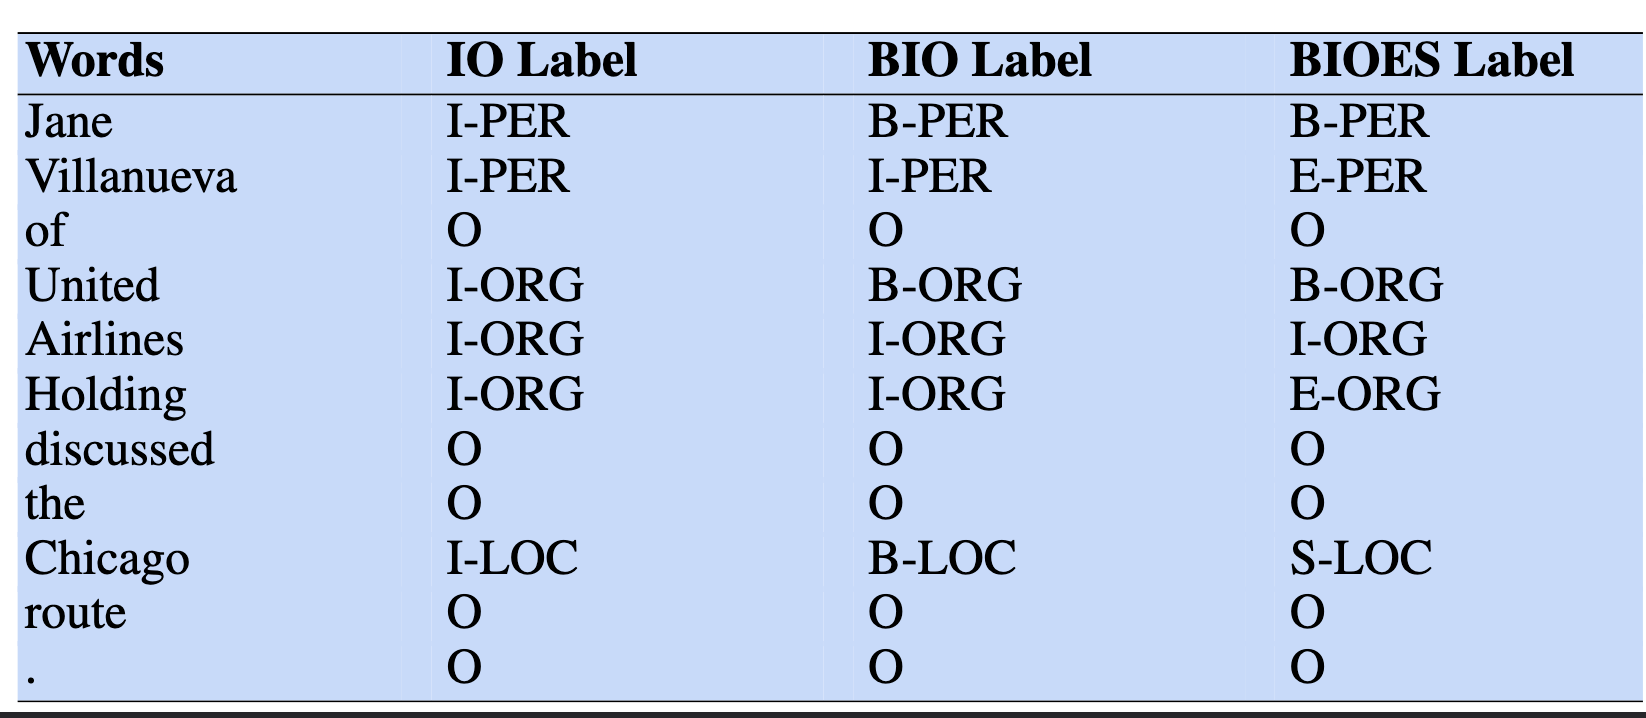

In [69]:
# Convert every sentence in the dataset to BIOES
all_bioes_tags = set()
for example in dataset["train"]:
    bio_str_tags = [label_names[t] for t in example["ner_tags"]]
    bioes_str_tags = bio_seq_to_bioes(bio_str_tags)
    all_bioes_tags.update(bioes_str_tags)

# Sort for stability: O first, then alphabetically
bioes_label_names = ["O"] + sorted(t for t in all_bioes_tags if t != "O")
bioes_id2label    = dict(enumerate(bioes_label_names))
bioes_label2id    = {v: k for k, v in bioes_id2label.items()}

print(f"BIOES tagset ({len(bioes_label_names)} labels):", bioes_label_names)


BIOES tagset (17 labels): ['O', 'B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'E-LOC', 'E-MISC', 'E-ORG', 'E-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'S-LOC', 'S-MISC', 'S-ORG', 'S-PER']


In [70]:
def add_labels_bioes(data):
    tokenized = tokenizer(
        data["tokens"],
        truncation=True,
        is_split_into_words=True,
    )

    all_labels = []
    for i, ner_tag_ids in enumerate(data["ner_tags"]):
        # firstly convert word-level BIO integer tags to BIO string tags
        bio_str = [label_names[t] for t in ner_tag_ids]

        # after convert word-level BIO strings to BIOES strings
        bioes_str = bio_seq_to_bioes(bio_str)

        # finally align BIOES word-level tags to subword tokens
        ids = tokenized.word_ids(batch_index=i)
        prev_word = None
        new_label = []

        # all the same except last else
        for wid in ids:
            if wid is None:
                new_label.append(-100)

            elif wid != prev_word:
                new_label.append(bioes_label2id[bioes_str[wid]])

            else:
                # use rules that were mentioned before
                tag = bioes_str[wid]
                entity_type = tag.split("-", 1)[1] if "-" in tag else None

                if tag.startswith("S-"):
                    # S-PER subword continuation - I-PER
                    new_label.append(bioes_label2id[f"I-{entity_type}"])
                elif tag.startswith("E-"):
                    # E-PER subword continuation - I-PER
                    new_label.append(bioes_label2id[f"I-{entity_type}"])
                elif tag.startswith("B-"):
                    # B-PER subword continuation - I-PER
                    new_label.append(bioes_label2id[f"I-{entity_type}"])
                else:
                    # I-PER or O keep the same
                    new_label.append(bioes_label2id[tag])

            prev_word = wid

        all_labels.append(new_label)

    tokenized["labels"] = all_labels
    return tokenized


tokenized_ds_bioes = dataset.map(
    add_labels_bioes,
    batched=True,
    remove_columns=dataset["train"].column_names,
)


Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [71]:
# BERT model with BIOES label head (17 output classes)
model_bioes = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=len(bioes_label_names),
    id2label=bioes_id2label,
    label2id=bioes_label2id,
)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

In [72]:
def eval_metric_bioes(preds):
    logits, labels = preds
    pred_ids = np.argmax(logits, axis=-1)
    true_seqs, pred_seqs = [], []

    for pred_seq, lab_seq in zip(pred_ids, labels):
        t, p = [], []
        for pr, lb in zip(pred_seq, lab_seq):
            if lb == -100:
                continue

            t.append(bioes_label_names[int(lb)])
            p.append(bioes_label_names[int(pr)])
        if t:
            true_seqs.append(t)
            pred_seqs.append(p)

    # seqeval auto-detects BIOES scheme from tag prefixes
    res = metric.compute(predictions=pred_seqs, references=true_seqs, zero_division=0)

    return {
        "precision": res["overall_precision"],
        "recall":    res["overall_recall"],
        "f1":        res["overall_f1"],
        "accuracy":  res["overall_accuracy"],
    }


In [73]:
training_args_bioes = TrainingArguments(
    output_dir="./results_bioes",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=n_epochs,
    fp16=torch.cuda.is_available(),
    logging_steps=100,
    save_strategy="no",
)

trainer_bioes = Trainer(
    model=model_bioes,
    args=training_args_bioes,
    train_dataset=tokenized_ds_bioes["train"],
    eval_dataset=tokenized_ds_bioes["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=eval_metric_bioes,
)

trainer_bioes.train()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
100,0.779406
200,0.148068
300,0.080014
400,0.052527
500,0.036905


TrainOutput(global_step=550, training_loss=0.20228251587260854, metrics={'train_runtime': 429.1175, 'train_samples_per_second': 163.603, 'train_steps_per_second': 1.282, 'total_flos': 2314972944016926.0, 'train_loss': 0.20228251587260854, 'epoch': 5.0})

In [74]:
bioes_test_output = trainer_bioes.predict(tokenized_ds_bioes["test"])
print(bioes_test_output.metrics)


{'test_loss': 0.3565913736820221, 'test_precision': 0.8833142857142857, 'test_recall': 0.9143499349343428, 'test_f1': 0.8985642039179214, 'test_accuracy': 0.9693512551015584, 'test_runtime': 9.202, 'test_samples_per_second': 375.244, 'test_steps_per_second': 2.934}


## Comparables

In [75]:
# Per-entity-type detailed metrics
def get_detailed_metrics(predictions_output, scheme_label_names):
    logits = predictions_output.predictions
    labels = predictions_output.label_ids
    pred_ids = np.argmax(logits, axis=-1)

    true_seqs, pred_seqs = [], []
    for pred_seq, lab_seq in zip(pred_ids, labels):
        t, p = [], []
        for pr, lb in zip(pred_seq, lab_seq):
            if lb == -100:
                continue
            t.append(scheme_label_names[int(lb)])
            p.append(scheme_label_names[int(pr)])
        if t:
            true_seqs.append(t)
            pred_seqs.append(p)

    res = metric.compute(predictions=pred_seqs, references=true_seqs, zero_division=0)

    overall = {
        "precision": res["overall_precision"],
        "recall":    res["overall_recall"],
        "f1":        res["overall_f1"],
        "accuracy":  res["overall_accuracy"],
    }

    # new here
    per_entity = {k: v for k, v in res.items() if isinstance(v, dict)}

    return overall, per_entity

In [76]:
res_bio = trainer.predict(tokenized_ds["test"])                # BIO
res_io = trainer_io.predict(tokenized_ds_io["test"])           # IO
res_bioes = trainer_bioes.predict(tokenized_ds_bioes["test"])  # BIOES

overall_bio, per_entity_bio = get_detailed_metrics(res_bio, label_names)
overall_io, per_entity_io = get_detailed_metrics(res_io, io_label_names)
overall_bioes, per_entity_bioes = get_detailed_metrics(res_bioes, bioes_label_names)

print("BIO overall:", overall_bio)
print("IO overall:", overall_io)
print("BIOES overall:", overall_bioes)

# overall comparable (like we did before)
summary = pd.DataFrame({
    "IO":    overall_io,
    "BIO":   overall_bio,
    "BIOES": overall_bioes,
}).T.round(4)

summary.index.name = "Scheme"
print(summary.to_markdown())

# Per-entity for each scheme
entity_types = ["PER", "ORG", "LOC", "MISC"]
per_entity_row = []
for etype in entity_types:
    per_entity_row.append({
        "Entity": etype,
        "IO F1": per_entity_io.get(etype, {}).get("f1", 0),
        "BIO F1": per_entity_bio.get(etype, {}).get("f1", 0),
        "BIOES F1": per_entity_bioes.get(etype, {}).get("f1", 0),
    })

df_per_entity = pd.DataFrame(per_entity_row).set_index("Entity").round(4)
print(df_per_entity.to_markdown())


BIO overall: {'precision': np.float64(0.8790721473648303), 'recall': np.float64(0.9125354107648725), 'f1': np.float64(0.8954912692207454), 'accuracy': 0.9715258190069491}
IO overall: {'precision': np.float64(0.7205240174672489), 'recall': np.float64(0.6449893390191898), 'f1': np.float64(0.6806675417213577), 'accuracy': 0.9333476903198019}
BIOES overall: {'precision': np.float64(0.8833142857142857), 'recall': np.float64(0.9143499349343428), 'f1': np.float64(0.8985642039179214), 'accuracy': 0.9693512551015584}
| Scheme   |   precision |   recall |     f1 |   accuracy |
|:---------|------------:|---------:|-------:|-----------:|
| IO       |      0.7205 |   0.645  | 0.6807 |     0.9333 |
| BIO      |      0.8791 |   0.9125 | 0.8955 |     0.9715 |
| BIOES    |      0.8833 |   0.9143 | 0.8986 |     0.9694 |
| Entity   |   IO F1 |   BIO F1 |   BIOES F1 |
|:---------|--------:|---------:|-----------:|
| PER      |  0.6686 |   0.9504 |     0.9515 |
| ORG      |  0.7088 |   0.8787 |     0.8841 

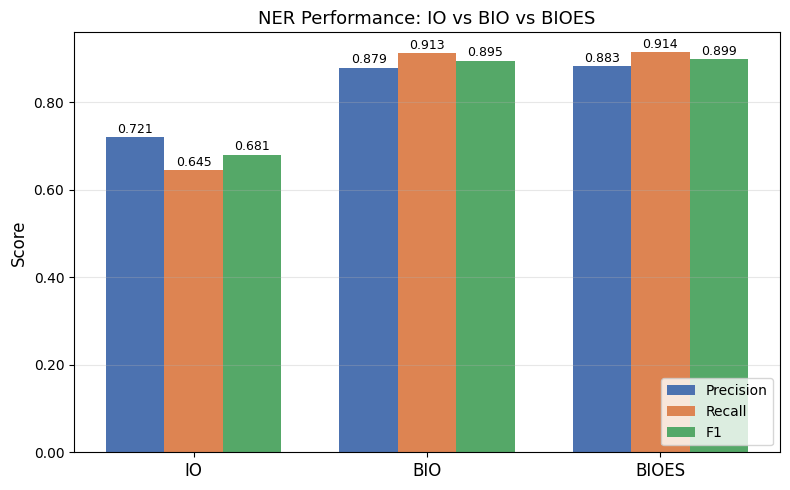

In [77]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(8, 5))

schemes = ["IO", "BIO", "BIOES"]
metrics_to_plot = ["precision", "recall", "f1"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

x = np.arange(len(schemes))
width = 0.25

for j, (met, color) in enumerate(zip(metrics_to_plot, colors)):
    values = [overall_io[met], overall_bio[met], overall_bioes[met]]
    bars = ax.bar(x + j * width, values, width, label=met.capitalize(), color=color)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(schemes, fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.set_ylabel("Score", fontsize=12)
ax.set_title("NER Performance: IO vs BIO vs BIOES", fontsize=13)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


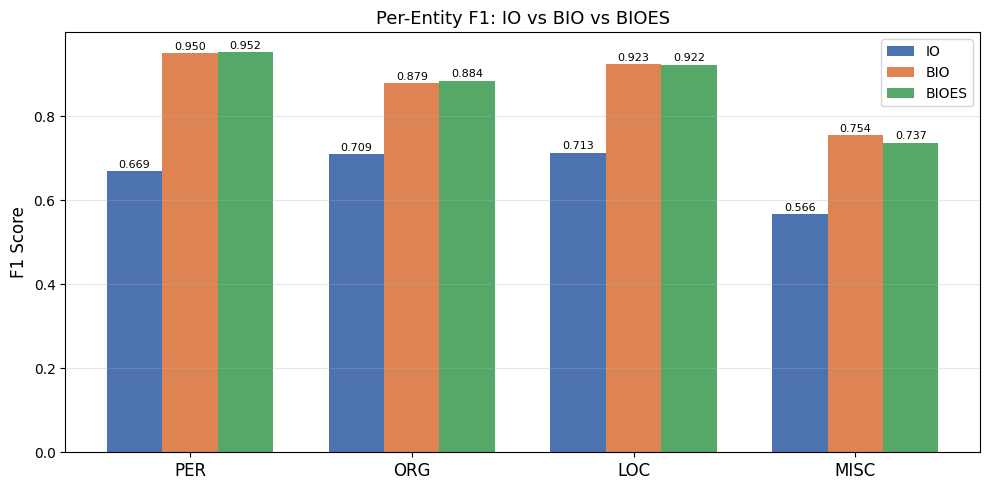

In [78]:
fig, ax = plt.subplots(figsize=(10, 5))

entity_types = ["PER", "ORG", "LOC", "MISC"]
x = np.arange(len(entity_types))
width = 0.25

scheme_colors = {"IO": "#4C72B0", "BIO": "#DD8452", "BIOES": "#55A868"}
scheme_data = {
    "IO":    [per_entity_io.get(e,    {}).get("f1", 0) for e in entity_types],
    "BIO":   [per_entity_bio.get(e,   {}).get("f1", 0) for e in entity_types],
    "BIOES": [per_entity_bioes.get(e, {}).get("f1", 0) for e in entity_types],
}

for j, (scheme, values) in enumerate(scheme_data.items()):
    bars = ax.bar(x + j * width, values, width,
                  label=scheme, color=scheme_colors[scheme])

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(entity_types, fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Per-Entity F1: IO vs BIO vs BIOES", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


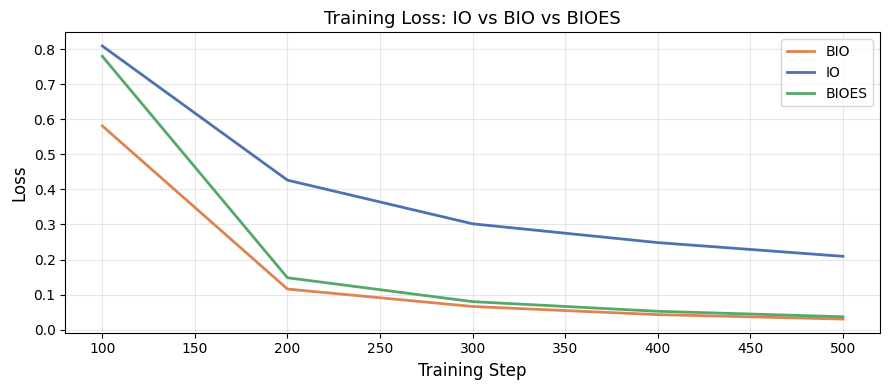

In [79]:
# Extract loss history from each trainer's state
def extract_loss(trainer_obj):
    return [
        (entry["step"], entry["loss"])
        for entry in trainer_obj.state.log_history
        if "loss" in entry
    ]

loss_bio = extract_loss(trainer)
loss_io = extract_loss(trainer_io)
loss_bioes = extract_loss(trainer_bioes)

fig, ax = plt.subplots(figsize=(9, 4))
for (loss_data, label, color) in [
    (loss_bio, "BIO", "#DD8452"),
    (loss_io, "IO", "#4C72B0"),
    (loss_bioes, "BIOES", "#55A868"),
]:
    steps, losses = zip(*loss_data)
    ax.plot(steps, losses, label=label, color=color, linewidth=2)

ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Training Loss: IO vs BIO vs BIOES", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [80]:
import torch

def predict_sentence(tokens, model_obj, scheme_label_names):
    model_obj.eval()
    model_obj.to(device)

    enc = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model_obj(**enc).logits  # (1, seq_len, num_labels)

    pred_ids = logits.argmax(-1)[0].tolist()
    word_ids = _ = tokenizer(tokens, is_split_into_words=True)
    word_ids = word_ids.word_ids(batch_index=0)

    result = []
    seen = set()
    for token_idx, wid in enumerate(word_ids):
        if wid is None or wid in seen:
            continue
        seen.add(wid)
        result.append((tokens[wid], scheme_label_names[pred_ids[token_idx]]))
    return result

for idx in range(5):
    example = dataset["test"][idx]
    tokens  = example["tokens"]
    true_tags = [label_names[t] for t in example["ner_tags"]]

    pred_bio   = predict_sentence(tokens, model,       label_names)
    pred_io    = predict_sentence(tokens, model_io,    io_label_names)
    pred_bioes = predict_sentence(tokens, model_bioes, bioes_label_names)

    print(f"Sentence {idx + 1}: {' '.join(tokens)}")
    print(f"{'Word':<18} {'True (BIO)':<12} {'IO pred':<12} {'BIO pred':<12} {'BIOES pred'}")
    for i, word in enumerate(tokens):
        print(f"{word:<18} {true_tags[i]:<12} {pred_io[i][1]:<12} {pred_bio[i][1]:<12} {pred_bioes[i][1]}")
    print()


Sentence 1: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
Word               True (BIO)   IO pred      BIO pred     BIOES pred
SOCCER             O            O            O            O
-                  O            O            O            O
JAPAN              B-LOC        O            B-ORG        S-PER
GET                O            O            O            O
LUCKY              O            O            B-PER        S-PER
WIN                O            O            O            O
,                  O            O            O            O
CHINA              B-PER        O            B-LOC        S-ORG
IN                 O            O            O            O
SURPRISE           O            O            O            O
DEFEAT             O            O            O            O
.                  O            O            O            O

Sentence 2: Nadim Ladki
Word               True (BIO)   IO pred      BIO pred     BIOES pred
Nadim              B-PER        I-P

In [81]:
from transformers import pipeline

# inference on random data
ner_bio = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    device=device,
    aggregation_strategy="simple"
)

ner_io = pipeline(
    "ner",
    model=model_io,
    tokenizer=tokenizer,
    device=device,
    aggregation_strategy="simple"
)

ner_bioes = pipeline(
    "ner",
    model=model_bioes,
    tokenizer=tokenizer,
    device=device,
    aggregation_strategy="simple"
)

# Test sentences — mix of entity types and adjacent entities
test_texts = [
    "Apple CEO Tim Cook announced new products in Cupertino, California.",
    "The European Union and United Nations held talks in Geneva.",
    "Elon Musk and Jeff Bezos both attended the SpaceX launch in Florida.",
    "Manchester United defeated Real Madrid 3-1 at Old Trafford.",
    "Barack Obama visited Microsoft headquarters in Seattle last Friday.",
    "The European Union signed an agreement with Apple in Brussels.",
    "Elon Musk and Tim Cook met at Stanford University in California."
]

def print_ner_comparison(text):
    print(f"\nText: {text}")

    for name, pipe in [("IO", ner_io), ("BIO", ner_bio), ("BIOES", ner_bioes)]:
        entities = pipe(text)
        ent_str = "  |  ".join(
            f"{e['word']} [{e['entity_group']}:{e['score']:.2f}]"
            for e in entities
        )
        print(f"{name:6s}: {ent_str if ent_str else '(no entities)'}")

for text in test_texts:
    print_ner_comparison(text)



Text: Apple CEO Tim Cook announced new products in Cupertino, California.
IO    : Apple [ORG:1.00]  |  Tim Cook [PER:1.00]  |  Cup [LOC:0.98]  |  ##ino [LOC:0.61]
BIO   : Apple [ORG:1.00]  |  Tim Cook [PER:1.00]  |  Cupertino [LOC:1.00]  |  California [LOC:1.00]
BIOES : Apple [ORG:1.00]  |  Tim [PER:1.00]  |  Cook [PER:1.00]  |  Cup [LOC:0.98]  |  ##ertino [LOC:1.00]  |  California [LOC:1.00]

Text: The European Union and United Nations held talks in Geneva.
IO    : European Union [ORG:1.00]  |  United Nations [ORG:1.00]  |  Geneva [LOC:0.99]
BIO   : European Union [ORG:1.00]  |  United Nations [ORG:1.00]  |  Geneva [LOC:1.00]
BIOES : European [ORG:1.00]  |  Union [ORG:1.00]  |  United [ORG:1.00]  |  Nations [ORG:1.00]  |  Geneva [LOC:1.00]

Text: Elon Musk and Jeff Bezos both attended the SpaceX launch in Florida.
IO    : Elon [PER:0.99]  |  ##sk and [PER:0.83]  |  ##s both [MISC:0.75]
BIO   : El [ORG:0.59]  |  ##on Musk [PER:0.81]  |  Jeff Bezos [PER:1.00]  |  SpaceX [MISC:0.85]  | 

In [82]:
# reduce any tag (B-PER, I-PER, S-PER, E-PER, I-PER) to its entity type or "O"
def to_entity_type(tag):
    return tag.split("-")[-1] if tag != "O" else "O"

def cm_token_level(true_seqs, pred_seqs):
    y_true = [to_entity_type(t) for seq in true_seqs for t in seq]
    y_pred = [to_entity_type(t) for seq in pred_seqs for t in seq]
    return confusion_matrix(y_true, y_pred, labels=ent_labels, normalize="true")

def predict_to_seqs(res, label_names_list):
    logits, labels = res.predictions, res.label_ids
    pred_ids = np.argmax(logits, axis=-1)
    true_seqs, pred_seqs = [], []
    for pred_seq, lab_seq in zip(pred_ids, labels):
        t, p = [], []
        for pr, lb in zip(pred_seq, lab_seq):
            if lb == -100:
                continue
            t.append(label_names_list[int(lb)])
            p.append(label_names_list[int(pr)])
        if t:
            true_seqs.append(t)
            pred_seqs.append(p)
    return true_seqs, pred_seqs

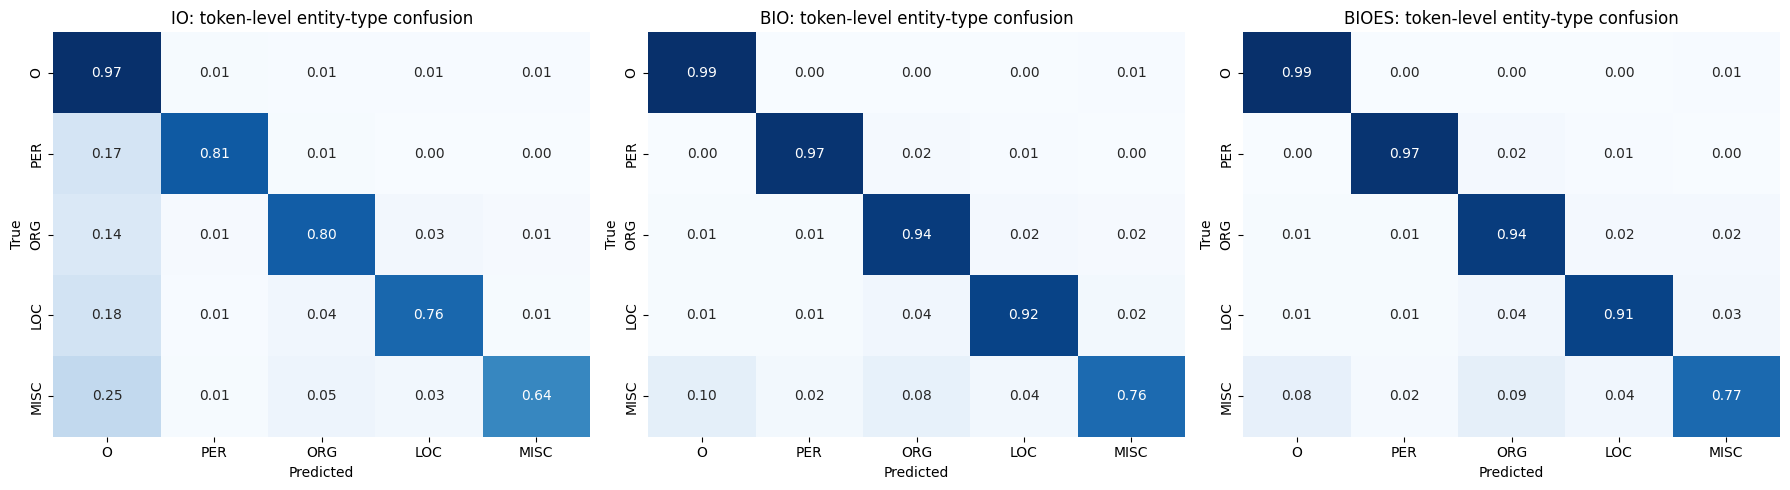

In [83]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

true_bio, pred_bio = predict_to_seqs(res_bio, label_names)
true_io, pred_io = predict_to_seqs(res_io, io_label_names)
true_bioes, pred_bioes = predict_to_seqs(res_bioes, bioes_label_names)
ent_labels = ["O", "PER", "ORG", "LOC", "MISC"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, (t_s, p_s) in zip(
    axes,
    ["IO", "BIO", "BIOES"],
    [(true_io, pred_io), (true_bio, pred_bio), (true_bioes, pred_bioes)],
):
    cm = cm_token_level(t_s, p_s)
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=ent_labels,
        yticklabels=ent_labels,
        ax=ax,
        cbar=False
    )

    ax.set_title(f"{name}: token-level entity-type confusion")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


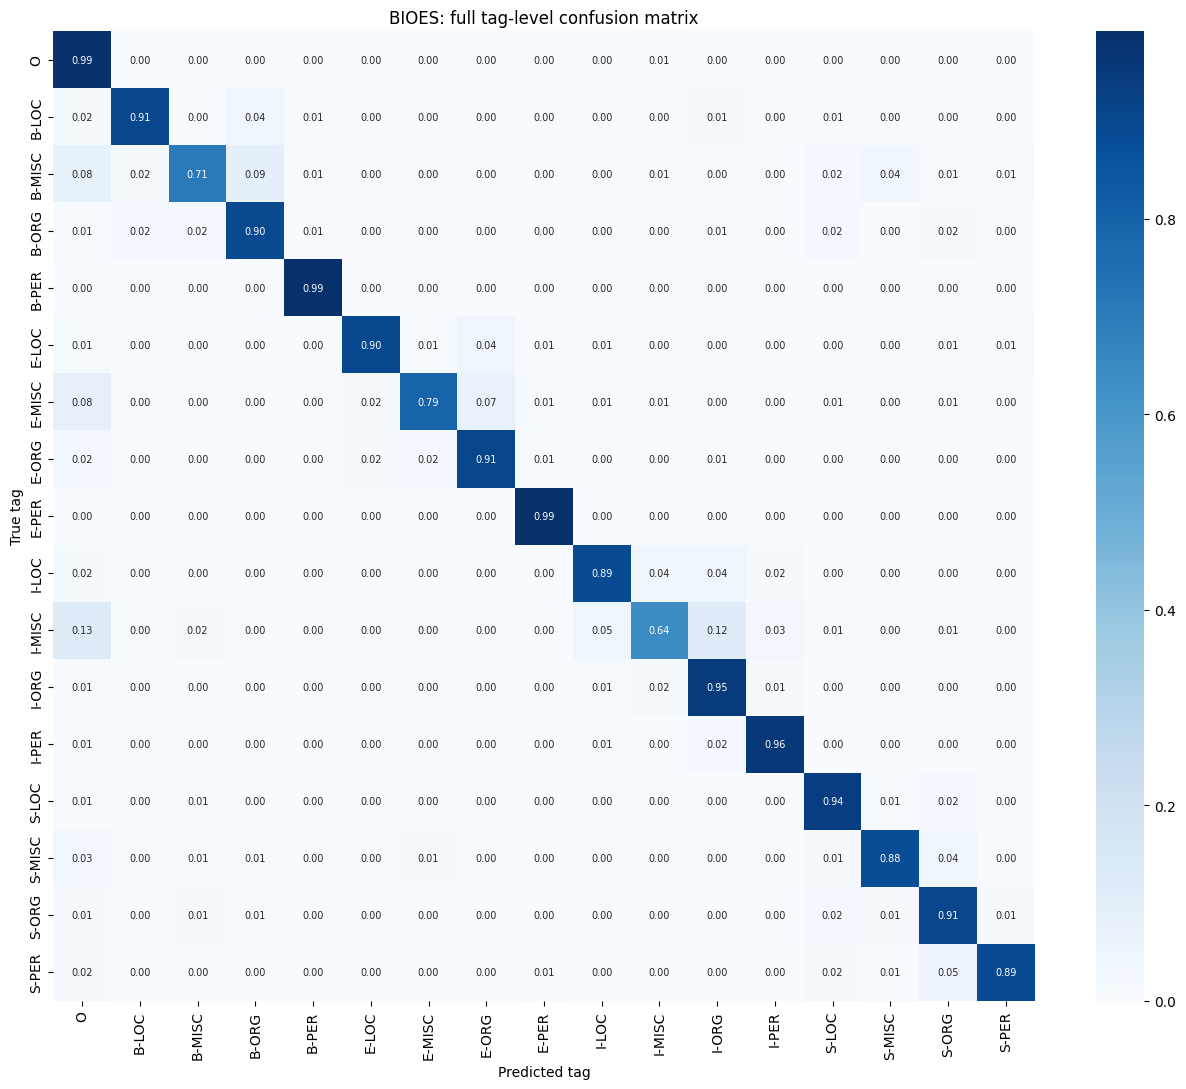

In [84]:
def cm_tag_level(true_seqs, pred_seqs, tag_list):
    y_true = [t for seq in true_seqs for t in seq]
    y_pred = [t for seq in pred_seqs for t in seq]
    return confusion_matrix(y_true, y_pred, labels=tag_list, normalize="true")

cm_bioes_full = cm_tag_level(true_bioes, pred_bioes, bioes_label_names)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    cm_bioes_full,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=bioes_label_names,
    yticklabels=bioes_label_names,
    ax=ax,
    cbar=True,
    annot_kws={"size": 7}
)

ax.set_title("BIOES: full tag-level confusion matrix")
ax.set_xlabel("Predicted tag")
ax.set_ylabel("True tag")
plt.tight_layout()
plt.show()
